# 1. Wstęp

Tematem analizy jest zbiór danych dotyczący zachowań ekstrawertyków i introwertyków. Celem pracy jest zbadanie różnic między tymi dwoma grupami osobowości oraz zidentyfikowanie cech, które mogą je wyróżniać. Zbiór danych został wybrany ze względu na jego potencjał do dostarczenia wglądu w różnice między ekstrawertykami a introwertykami. Analiza tego zbioru może pomóc zrozumieć, jakie cechy i zachowania są typowe dla każdej z tych grup, co może mieć praktyczne zastosowanie w różnych dziedzinach, takich jak edukacja, zarządzanie zasobami ludzkimi czy rozwój osobisty.

# 2. Opis zbioru danych

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("personality_dataset.csv")

In [3]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [5]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [6]:
for col in df.select_dtypes(exclude=["number"]).columns:
    print(col, ":", df[col].unique())

Stage_fear : <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Drained_after_socializing : <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Personality : <StringArray>
['Extrovert', 'Introvert']
Length: 2, dtype: str


Analizowany zbiór danych "Extrovert vs. Introvert Behavior Data" pochodzi z platformy [Kaggle](https://www.kaggle.com/datasets/rakeshkapilavai/extrovert-vs-introvert-behavior-data?resource=download&select=personality_dataset.csv).
Dane zostały udostępnione przez
Rakesh Kapilavayi. Informacja o ich pochodzeniu oraz sposobie zebrania bądź wygenerowania nie została udostępniona ani opisana.


Analizowany zbiór składa się z 8 zmienny oraz 2900 obserwacji.
Dane zawierają zbiór cech związanych z codziennymi aktywnościami, wzorami badź odczuciami badanych. Dodatkowo zbiór zawiera informacje o tym jaka jest osobowość osoby - ekstrawertyk bądź introwertyk.

***Zmienne w zbiorze to***

**Time_spent_Alone**

Zmienna ilościowa wyrażająca ilość godzin spędzonych samotnie przez jednostkę w trakcie dnia. Jest wyrażona w godzinach. Cecha ta wydaje się być istotna w kontekście badanego zbioru. Duże spędzanie czasu w samotności często bywa powiązane z osobowością introwertyczną, jednak należy mieć na uwadzę, że istnieją też inne powody dla których jednostka może spędzać dużo czasu w domu jak na przykład tryb pracy.

**Stage_fear**

Zmienna jakościowa binarna przyjmująca wartości "Yes"/"No" stwierdzająca czy u badanego występuje strach przed wystąpieniami publicznymi. Pozornie może się wydawać, że jest to częśiej powiązane ze stylem introwertycznym jednak strach przed wystąpieniami jest [rodzajem fobii](https://harmonicvoice.pl/glossofobia-czyli-strach-przed-wystapieniami-publicznymi/), która nie jest jednoznacznie powiązana z tą grupą.


**Social_event_attendance**

Zmienna ilościowa określająca częstość  uczęszczania w wydarzeniach towarzyskich. Jest wyrażona w skali 0-10. Cecha ta wydaje się mieć istotne znaczenie, bowiem inormuje o tym w jaki sposób jednostka spędza swój czas.

**Going_outside**

Zmienna ilościowa określająca częstostość wychodzenia z domu. Jest wyrażona w skali 0-10. Podobnie jak powyższa informuje w jaki sposób badany spędza swój czas. Nie określono jednak jasno jaki charakter mają te wyjścia - czy są związane z obowiązkiem zawodowym, życiem społecznym bądź załatwianiem codziennych sprawunków. Nie wskazano również czy wyjścia były w pojedynke czy w grupie.

**Drained_after_socializing**

Zmienna binarna przyjmująca wartości "Yes"/"No". Określa czy jednostka czuje się zmęczona po kontaktach z innymi. Wydaje się być szczególnie ważna, ponieważ bezpośrednio informuje o odczuciach jednostki.

**Friends_circle_size**

Zmienna ilościowa informująca o ilości bliskich znajomych. W przedstawionym problemie wydaje się mieć istotny wpływ. Uważa się, że osoby ekstrawertyczne mają w zwyczaju otaczać się wiekszą grupą znajomych.

**Post_frequency**

Zmienna ilościowa określająca częstotliwość udostępniania postów na social mediach. Jest wyrażona w skali 0-10. Może wydawać się że osoby ekstrawertyczne mają silniejszą chęć dzielenia się swoim życiem.

**Personality**

Zmienna jakościowa przyjmująca wartości "Extrovert"/"Introvert". W kontekście tego zbioru jest to głowna zmienna, która mogłaby by być zmienną przewidywaną na podstawie pozostałych cech

# 3. Przygotowanie danych

In [7]:
df.isna().mean().round(2)

Time_spent_Alone             0.02
Stage_fear                   0.03
Social_event_attendance      0.02
Going_outside                0.02
Drained_after_socializing    0.02
Friends_circle_size          0.03
Post_frequency               0.02
Personality                  0.00
dtype: float64

In [8]:
df.drop(columns=["Personality"]).isna().groupby(df["Personality"]).mean().round(2).T

Personality,Extrovert,Introvert
Time_spent_Alone,0.02,0.02
Stage_fear,0.03,0.02
Social_event_attendance,0.02,0.02
Going_outside,0.02,0.02
Drained_after_socializing,0.01,0.02
Friends_circle_size,0.03,0.03
Post_frequency,0.02,0.02


In [9]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [10]:
df["Stage_fear"].value_counts(dropna=False)

Stage_fear
No     1417
Yes    1410
NaN      73
Name: count, dtype: int64

In [11]:
df["Drained_after_socializing"].value_counts(dropna=False)

Drained_after_socializing
No     1441
Yes    1407
NaN      52
Name: count, dtype: int64

In [12]:
df["Personality"].value_counts(dropna=False)

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

In [13]:
def fill_missing_with_median_by_group(df, col, group_col="Personality"):
    df[col] = df.groupby(group_col)[col].transform(lambda x: x.fillna(x.median()))


def fill_missing_with_mode_by_group(df, col, group_col="Personality"):
    df[col] = df.groupby(group_col)[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
    )


fill_missing_with_median_by_group(df, "Time_spent_Alone")
fill_missing_with_median_by_group(df, "Social_event_attendance")
fill_missing_with_median_by_group(df, "Going_outside")
fill_missing_with_median_by_group(df, "Friends_circle_size")
fill_missing_with_median_by_group(df, "Post_frequency")

fill_missing_with_mode_by_group(df, "Stage_fear")
fill_missing_with_mode_by_group(df, "Drained_after_socializing")

In [14]:
df.isna().mean().round(2)

Time_spent_Alone             0.0
Stage_fear                   0.0
Social_event_attendance      0.0
Going_outside                0.0
Drained_after_socializing    0.0
Friends_circle_size          0.0
Post_frequency               0.0
Personality                  0.0
dtype: float64

W zbiorze danych nie zidentyfikowany żadnych wartości nietypowych bądź podejrzanych. Dane nie wymagały przekształceń zmiennych. Wszystkie cechy wydają się istotne dla przedstawionego problemu, więc żadna nie została usunięta.

W zbiorze występują braki dla danych. Dla kolumny Time_spent_Alone - 2%, Stage_fear - 3%, Social_event_attendance - 2%, Going_outside - 2%, Drained_after_socializing - 2%, Friends_circle_size - 3%, Post_frequency - 2%. Dodatkowo sprawdzono i rozkład braków dla obu z typów osobowości jest taki sam co wzkazuje na to że braki nie sa powiązane tylko jedną z grup.

Proces uzupełniania brakujących wartości rozpoczęto od pogrupowania zbioru według kolumny Personality. Dla każdej z grup dla zmiennych jakościowych z brakującą wartością policzono modę, a dla ilościowych medianę. Na tym etapie nie posiadamy jeszcze inormacji o rozkładach zmiennych (zostaną sprawdzone w kolejnych punktach) co czyni użycie mediany metodę bezpieczniejszą odporną na wartości odstające w porównaniu do użycia średniej.








# 4. Statystyki opisowe

In [15]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Zmienne ilościowe:", num_cols)
print("Zmienne jakościowe:", cat_cols)

Zmienne ilościowe: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
Zmienne jakościowe: ['Stage_fear', 'Drained_after_socializing', 'Personality']


In [16]:
def quantitative_stats(s):
    mean_ = s.mean()
    median_ = s.median()
    mode_ = s.mode().iloc[0] if not s.mode().empty else np.nan
    min_ = s.min()
    max_ = s.max()
    range_ = max_ - min_
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    var_ = s.var()
    std_ = s.std()
    cv = (std_ / mean_) * 100 if mean_ != 0 else np.nan
    skew_ = skew(s, bias=False)
    kurt_ = kurtosis(s, bias=False)

    result = pd.Series({
        "średnia": mean_,
        "mediana": median_,
        "dominanta": mode_,
        "minimum": min_,
        "maksimum": max_,
        "rozstęp": range_,
        "Q1": q1,
        "Q3": q3,
        "rozstęp międzykwartylowy": iqr,
        "wariancja": var_,
        "odchylenie standardowe": std_,
        "współczynnik zmienności [%]": cv,
        "skośność": skew_,
        "kurtoza": kurt_
    })

    return result


In [17]:
def categorical_stats(s):
    counts = s.value_counts()
    frequencies = s.value_counts(normalize=True)
    percentages = frequencies * 100
    mode = s.mode().iloc[0]

    counts_str = ", ".join([f"{k}: {v}" for k, v in counts.items()])
    freq_str = ", ".join([f"{k}: {v:.3f}" for k, v in frequencies.items()])
    perc_str = ", ".join([f"{k}: {v:.2f}%" for k, v in percentages.items()])

    result = pd.Series({
        "liczebność": counts_str,
        "częstość": freq_str,
        "udział procentowy": perc_str,
        "dominanta": mode,
    })

    return result

In [18]:
quant_summary = pd.DataFrame({col: quantitative_stats(df[col]) for col in num_cols}).T
quant_summary.T

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
średnia,4.501379,3.960000,3.002759,6.264828,3.564138
mediana,4.000000,3.000000,3.000000,5.000000,3.000000
dominanta,2.000000,2.000000,0.000000,3.000000,1.000000
minimum,0.000000,0.000000,0.000000,0.000000,0.000000
maksimum,11.000000,10.000000,7.000000,15.000000,10.000000
rozstęp,11.000000,10.000000,7.000000,15.000000,10.000000
Q1,2.000000,2.000000,1.000000,3.000000,1.000000
Q3,7.000000,6.000000,5.000000,10.000000,6.000000
rozstęp międzykwartylowy,5.000000,4.000000,4.000000,7.000000,5.000000
wariancja,11.977577,8.337137,5.026553,18.151988,8.512960


**Time_spent_Alone**

Średni czas spędzany samotnie wynosi około 4,50, a mediana 4, co oznacza, że typowa osoba w zbiorze spędza samotnie około 4 godzin. Dominanta równa
2 wskazuje, że najczęściej pojawiającą się wartością jest 2. Wartości zmiennej mieszczą się od 0 do 11 rozstęp wynosi 11. Pierwszy kwartyl to
2, a trzeci kwartyl 7, więc połowa obserwacji znajduje się w przedziale od 2 do 7. Odchylenie standardowe równe 3,00 oraz współczynnik zmienności około 76,88% sugerują spore zróżnicowanie. Skośność jest dodatnia, co oznacza, że rozkład ma lekko prawostronny ogon, czyli część osób spędza znacznie więcej czasu samotnie niż większość badanych. Ujemna kurtoza (-1,15) wskazuje na płaski rozkład bez wyraźnej koncentracji wokół średniej.

**Social_event_attendance**


Średnia wartość tej zmiennej wynosi około 3,96, a mediana 3. Dominanta równa 2 oznacza, że najczęściej badani przyjmują właśnie tę wartość. Zakres wartości od 0 do 10 pokazuje. Kwartyle 2 i 6 wskazują, że połowa wyników mieści się w przedziale od 2 do 6. Odchylenie standardowe wynoszące około 3,00 oraz współczynnik zmienności 72,91% świadczą o sporym rozproszeniu danych. Dodatnia skośność oznacza, że większość obserwacji skupia się przy niższych wartościach, a wyższe wyniki pojawiają się rzadziej.

**Going_outside**


Średnia wartość tej cechy wynosi około 3,00, a mediana
3, co oznacza, że typowa osoba wychodzi z domu około 3 razy w jednostce skali użytej w badaniu. Dominanta równa 0 sugeruje, że bardzo wielu badanych w ogóle nie wychodzi lub wychodzi bardzo rzadko. Wartości zmiennej wahają się od 0 do 7, więc rozstęp wynosi 7. Kwartyle 1 i 5 pokazują, że połowa wyników znajduje się między 1 a 5. Odchylenie standardowe około 2,00 i współczynnik zmienności 74,66%. Skośność dodatnia oznacza, że więcej osób osiąga niskie wartości, a wysokie występują rzadziej.

**Friends_circle_size**


Średnia liczba bliskich znajomych wynosi około 6,26, a mediana 5, co oznacza, że typowa osoba ma około 5 bliskich znajomych, choć średnia jest nieco wyższa. Dominanta równa
3 pokazuje, że najczęściej pojawiającą się wartością jest 3. Zakres od 0 do 15 daje rozstęp równy 15, czyli jest to jedna z najbardziej zróżnicowanych cech. Kwartyle
3 i 10 wskazują, że połowa badanych ma od 3 do 10 bliskich znajomych. Odchylenie standardowe około 3,00 oraz współczynnik zmienności 68,15%. Dodatnia skośność sugeruje, że większość osób ma raczej mniejsze lub średnie grono znajomych, a większe wartości pojawiają się rzadziej.

**Post_frequency**


Średnia częstotliwość publikowania postów wynosi około 3,56, a mediana
3, co oznacza umiarkowanie niską aktywność w mediach społecznościowych. Dominanta równa 1 wskazuje, że najczęściej występuje bardzo niska częstotliwość publikacji. Wartości zmiennej mieszczą się od 0 do 10, więc rozstęp wynosi 10. Kwartyle 1 i 6 pokazują, że połowa wyników zawiera się w przedziale od 1 do 6. Odchylenie standardowe około 3,00 i współczynnik zmienności 81,86%. Dodatnia skośność oznacza, że więcej osób publikuje rzadko, a tylko część badanych publikuje bardzo często

In [19]:
cat_summary = pd.DataFrame({col: categorical_stats(df[col]) for col in cat_cols}).T
cat_summary.T

,Stage_fear,Drained_after_socializing,Personality
liczebność,"No: 1459, Yes: 1441","No: 1459, Yes: 1441","Extrovert: 1491, Introvert: 1409"
częstość,"No: 0.503, Yes: 0.497","No: 0.503, Yes: 0.497","Extrovert: 0.514, Introvert: 0.486"
udział procentowy,"No: 50.31%, Yes: 49.69%","No: 50.31%, Yes: 49.69%","Extrovert: 51.41%, Introvert: 48.59%"
dominanta,No,No,Extrovert


**Stage_fear**

W badanej próbie liczba osób deklarujących brak strachu (No: 1459) jest bardzo zbliżona do liczby osób odczuwających strach (Yes: 1441). Częstości wynoszą odpowiednio 0,503 i 0,497, co przekłada się na 50,31% i 49,69%. Dominanta to odpowiedź „No”, jednak różnica jest minimalna. Badana populacja jest niemal równo podzielona pod względem strachu przed wystąpieniami publicznymi - nieznacznie przeważają osoby, które go nie odczuwają.

**Drained_after_socializing**

Rozkład odpowiedzi jest taki sam jak w przypadku poprzedniej zmiennej: 1459 osób (50,31%) deklaruje brak zmęczenia, a 1441 osób (49,69%) jego odczuwanie. Częstości wynoszą odpowiednio 0,503 i 0,497. Dominanta to „No”, ale przewaga jest niewielka. Populacja jest niemal idealnie zrównoważona - połowa osób odczuwa zmęczenie po interakcjach społecznych, a połowa nie.

**Personality**

W przypadku tej zmiennej 1491 osób (51,41%) określa się jako ekstrawertycy, a 1409 osób (48,59%) jako introwertycy. Częstości wynoszą odpowiednio 0,514 i 0,486.
Dominanta to „Extrovert”, co oznacza niewielką przewagę osób ekstrawertycznych.


# 5. Wizualizacja danych

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   str    
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   str    
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


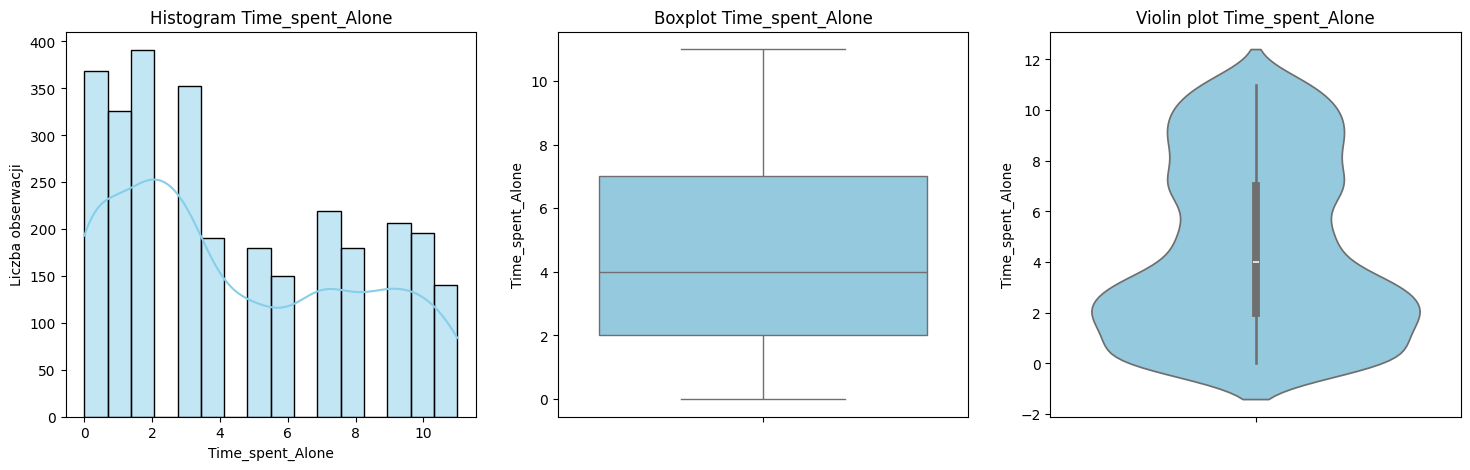

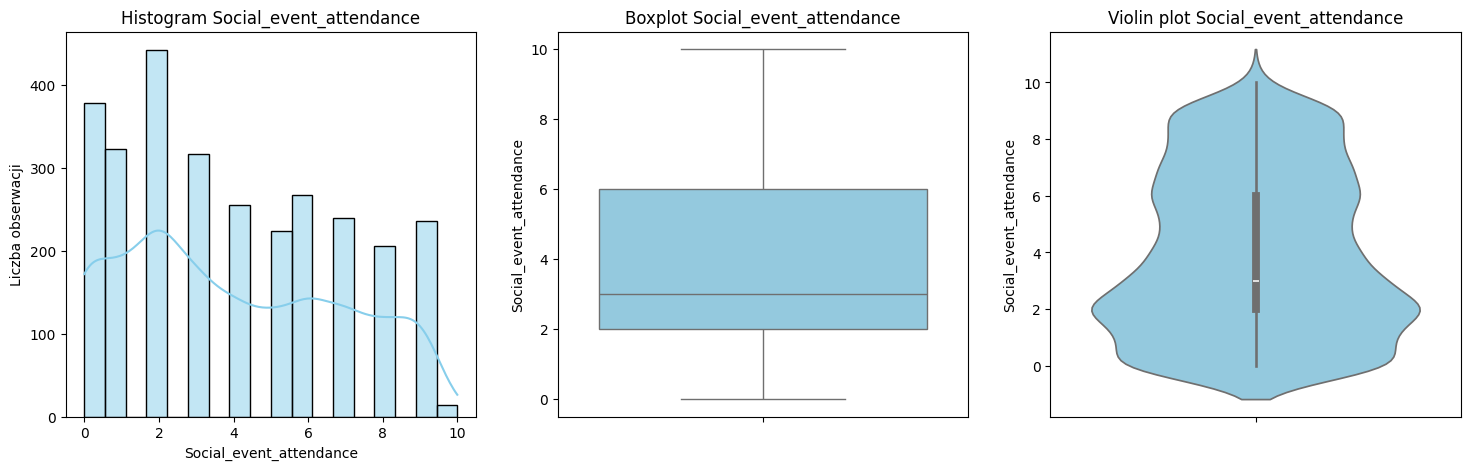

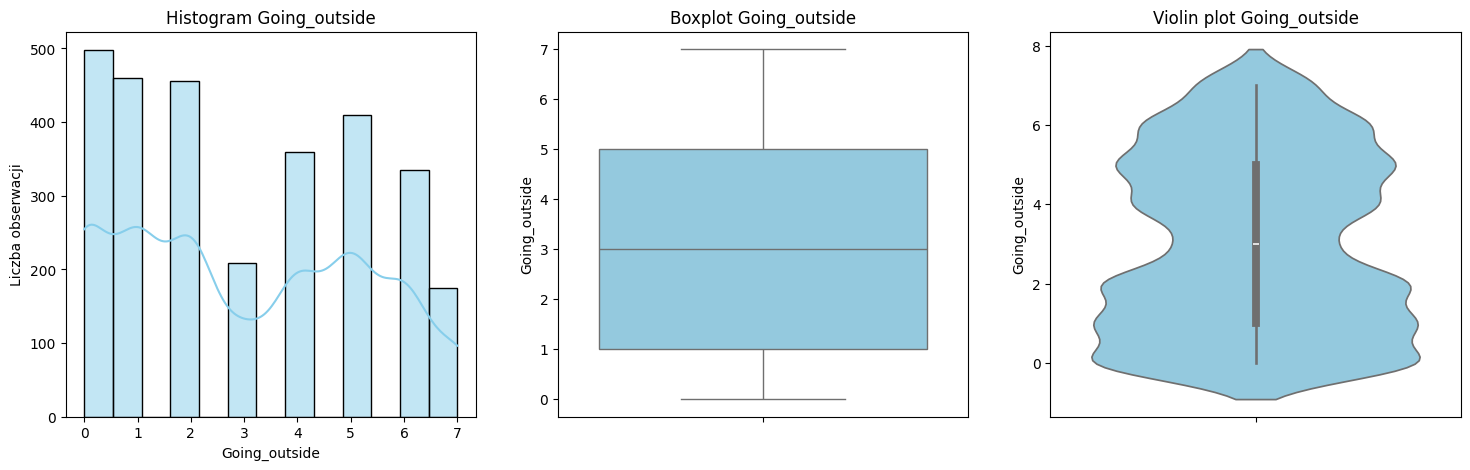

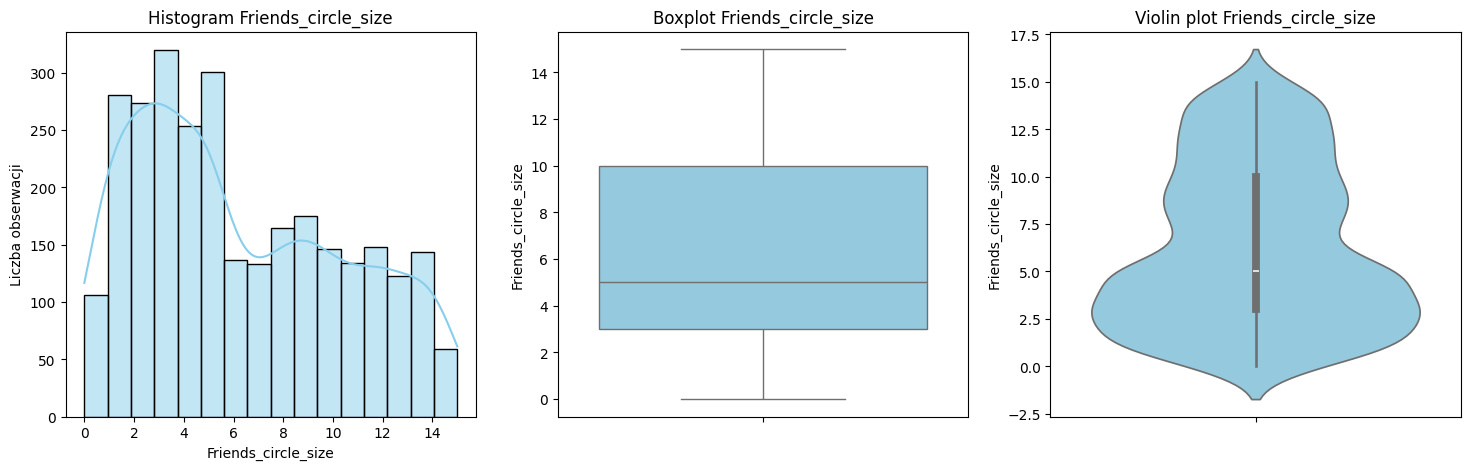

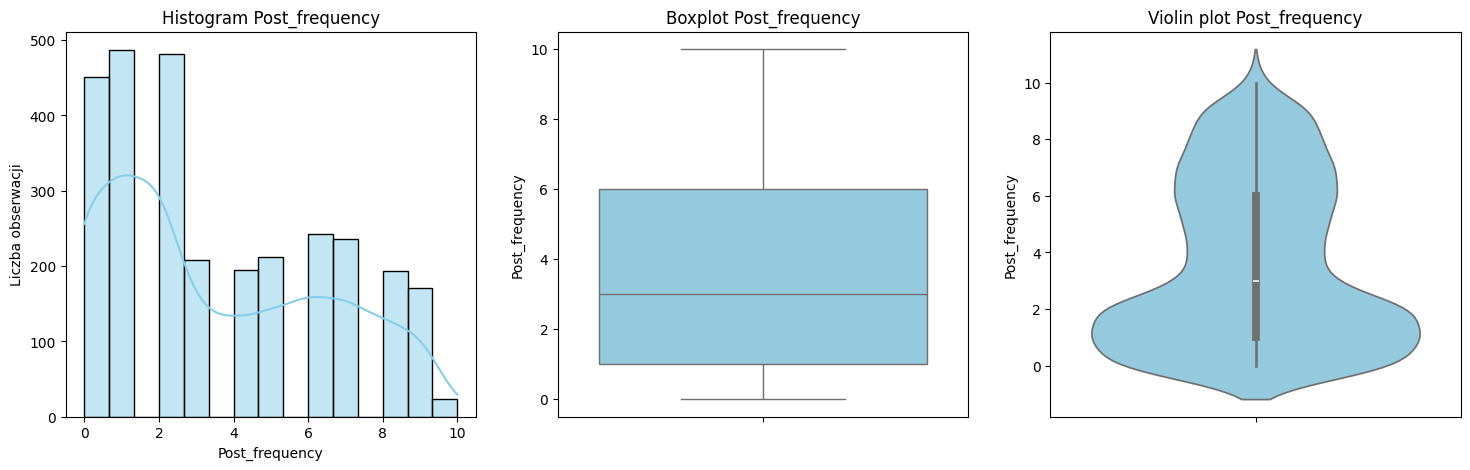

In [21]:
for col in num_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(df[col], kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f"Histogram {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Liczba obserwacji")

    sns.boxplot(y=df[col], ax=axes[1], color="skyblue")
    axes[1].set_title(f"Boxplot {col}")
    axes[1].set_ylabel(col)

    sns.violinplot(y=df[col], ax=axes[2], color="skyblue")
    axes[2].set_title(f"Violin plot {col}")
    axes[2].set_ylabel(col)

**Time_spent_Alone**

Rozkład zmiennej jest asymetryczny prawoskośny z największym skupiskiem obserwacji w przedziale od 0 do 4. Mediana badanego czasu wynosi 4, a środkowa połowa wyników mieści się w przedziale od 2 do 7, przy całkowitym braku wartości skrajnych.

**Social_event_attendance**

Rozkład zmiennej jest prawoskośny z największym nagromadzeniem obserwacji w dolnym przedziale wartości (od 0 do 3). Mediana badanego zjawiska wynosi 3, a środkowa połowa wyników mieści się w przedziale międzykwartylowym od 2 do 6, przy całkowitym braku wartości odstających.

**Going_outside**

Rozkład zmiennej jest z lekką asymetrią prawostronną, co objawia się nagromadzeniem obserwacji na dwóch przeciwległych krańcach badanej skali. Mediana dla tej zmiennej wynosi 3, a środkowa połowa wyników mieści się w przedziale międzykwartylowym od 1 do 5, przy jednoczesnym braku jakichkolwiek wartości odstających. Zarysowuje się podział na liczną grupę osób rzadko wychodzących na zewnątrz (wartości 0-2) oraz drugą, równie dużą grupę osób wychodzących częściej (wartości 4-6), które są od siebie oddzielone wyraźnym spadkiem liczebności wokół samej mediany.

**Friends_circle_size**

Rozkład zmiennej jest prawoskośny z wyraźnie zarysowanym największym skupiskiem obserwacji dla stosunkowo niskich wartości (od 1 do 5). Mediana dla tej badanej zmiennej wynosi 5, a środkowa połowa wyników charakteryzuje się sporym rozrzutem i mieści się w przedziale międzykwartylowym od 3 do 10, przy całkowitym braku wartości odstających.

**Post_frequency**

Rozkład zmiennej jest prawoskośny z wyraźnie największym nagromadzeniem obserwacji w początkowym przedziale skali (wartości od 0 do 3). Mediana badanego zjawiska wynosi 3, a środkowa połowa wyników cechuje się sporym rozproszeniem i mieści się w przedziale międzykwartylowym od 1 do 6, przy braku wartości skrajnych.
















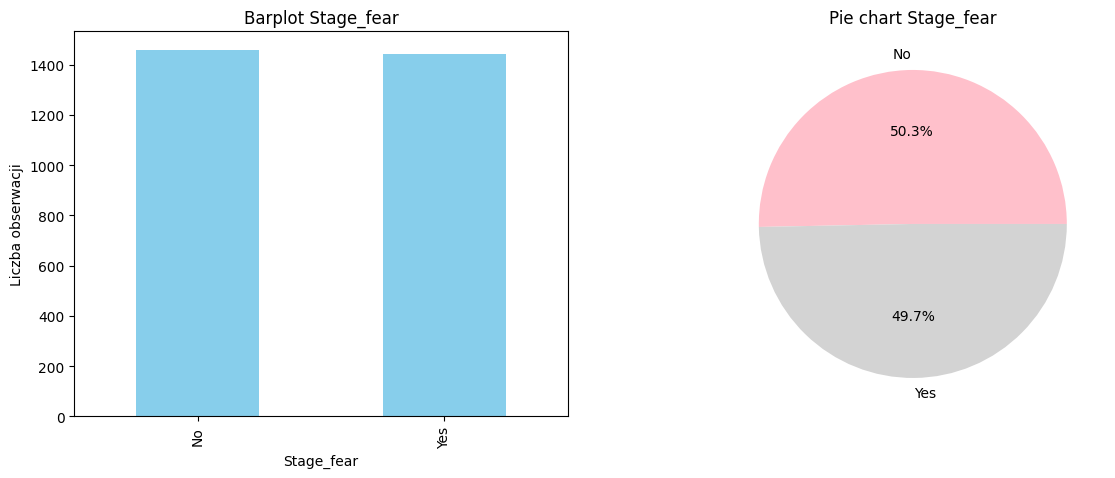

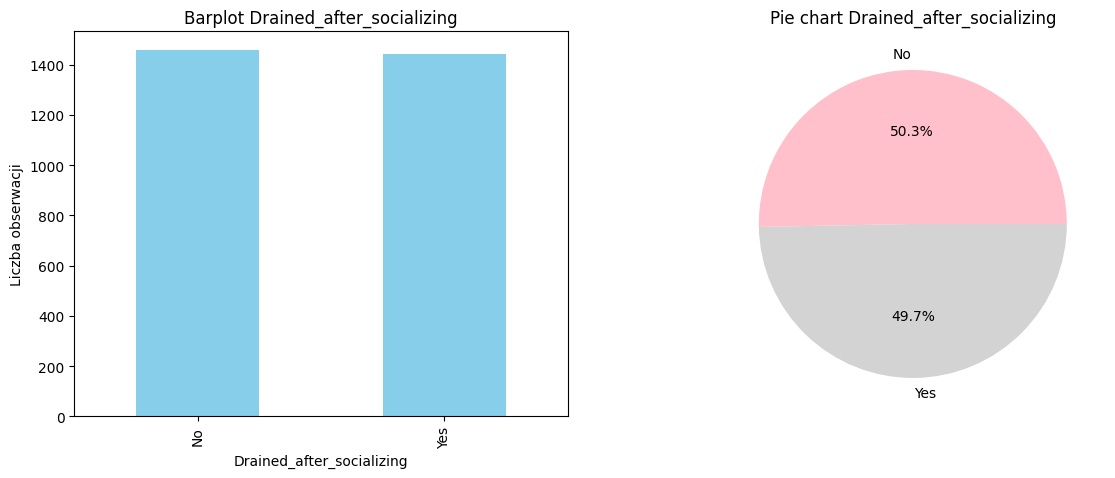

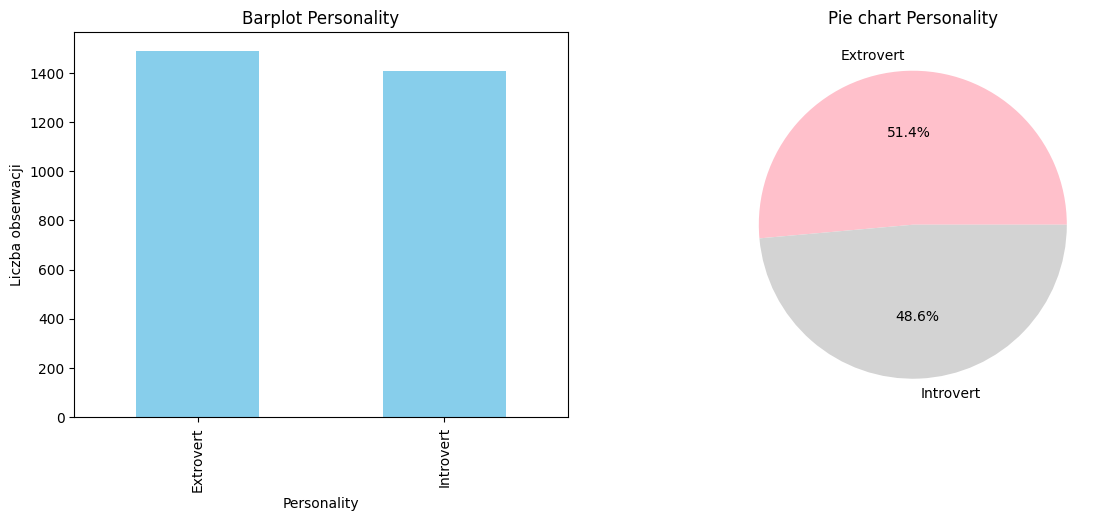

In [22]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df[col].value_counts().plot(kind="bar", ax=axes[0], color="skyblue")
    axes[0].set_title(f"Barplot {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Liczba obserwacji")

    df[col].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[1], colors=["pink", "lightgray"])
    axes[1].set_title(f"Pie chart {col}")
    axes[1].set_ylabel("")

**Stage_fear**

Rozkład odpowiedzi dzieli się tutaj prawie pół na pół. 50,3% badanych twierdzi, że nie ma problemu z wystąpieniami publicznymi, podczas gdy 49,7% odczuwa przed nimi stres. Wychodzi na to, że lęk przed prezentowaniem czegoś na forum dotyczy połowy tej grupy.

**Drained_after_socializing**

W tym przypadku proporcje są identyczne i znów dzielą populację na prawie równe połowy. 50,3% osób nie czuje zmęczenia po kontaktach towarzyskich, a 49,7% deklaruje wyraźny spadek energii. Grupa dzieli się prawie po równo na osoby, które interakcje męczą bądź znoszą je bez problemu.

**Personality**

Podział na typy osobowości też jest bardzo wyrównany, chociaż z delikatną przewagą jednej ze stron. Ekstrawertycy stanowią 51,4% ogółu, a introwertycy 48,6%. Różnica jest na tyle mała (niecałe 3 punkty procentowe), że zbiór danych jest pod tym kątem dobrze zbalansowany.

# 6. Porównanie względem cechy jakościowej

In [23]:
print(df.groupby("Personality")["Time_spent_Alone"].apply(quantitative_stats).unstack().T)

Personality                   Extrovert  Introvert
średnia                        2.065728   7.078779
mediana                        2.000000   7.000000
dominanta                      2.000000   7.000000
minimum                        0.000000   0.000000
maksimum                      11.000000  11.000000
rozstęp                       11.000000  11.000000
Q1                             1.000000   5.000000
Q3                             3.000000   9.000000
rozstęp międzykwartylowy       2.000000   4.000000
wariancja                      4.767489   6.686261
odchylenie standardowe         2.183458   2.585781
współczynnik zmienności [%]  105.699219  36.528622
skośność                       2.158678  -0.431066
kurtoza                        5.568116  -0.310512


In [24]:
df.groupby("Personality")["Time_spent_Alone"].apply(quantitative_stats).unstack().T

Personality,Extrovert,Introvert
średnia,2.065728,7.078779
mediana,2.000000,7.000000
dominanta,2.000000,7.000000
minimum,0.000000,0.000000
maksimum,11.000000,11.000000
rozstęp,11.000000,11.000000
Q1,1.000000,5.000000
Q3,3.000000,9.000000
rozstęp międzykwartylowy,2.000000,4.000000
wariancja,4.767489,6.686261


Text(0, 0.5, 'Time_spent_Alone')

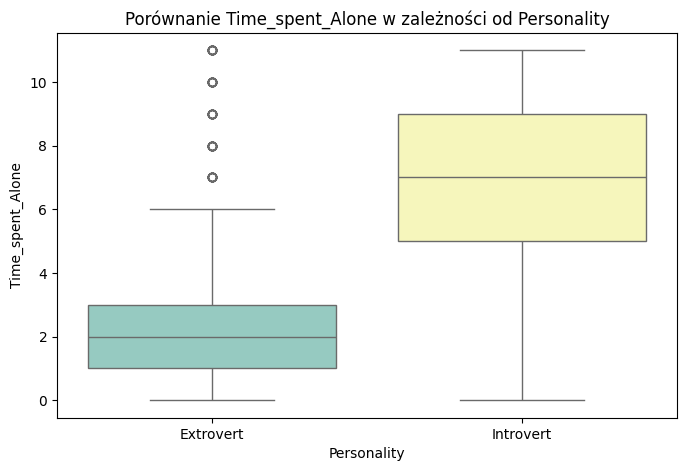

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Personality", y="Time_spent_Alone", data=df, palette="Set3", hue="Personality")

plt.title("Porównanie Time_spent_Alone w zależności od Personality")
plt.xlabel("Personality")
plt.ylabel("Time_spent_Alone")

Zestawienie wyraźnie pokazuje istotne różnice między ekstrawertykami a introwertykami pod względem czasu spędzanego w samotności.

Introwertycy spędzają zdecydowanie więcej czasu sami ich średnia ok. 7,08 i mediana 7 są ponad trzykrotnie wyższe niż u ekstrawertyków, średnia ok. 2,07, mediana 2. Rozkład dla introwertyków jest też bardziej rozciągnięty IQR=4 a IQR=2 , co oznacza większe zróżnicowanie w tej grupie.

Ekstrawertycy koncentrują się wokół niskich wartości (Q1 = 1, Q3 = 3), ale mają wyraźną prawostronną skośność (2,16) i wysoką kurtozę, co wskazuje na obecność wartości odstających, co jest również widoczne na boxplocie. 

W przypadku introwertyków rozkład jest bardziej symetryczny, lewoskośny, bez wartości odstających.

# 7. Analiza zależności między zmiennymi

Text(0, 0.5, 'Time_spent_Alone')

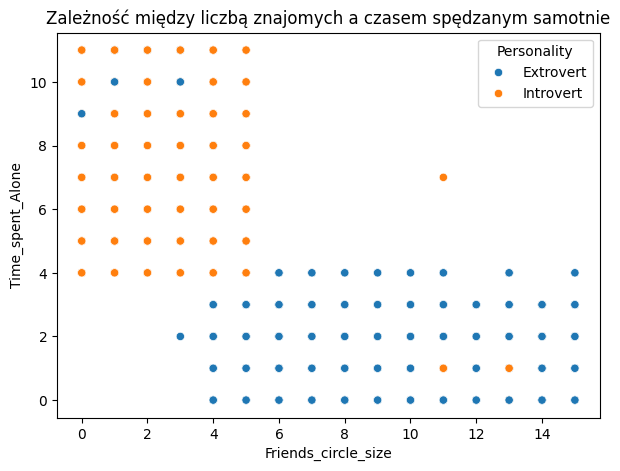

In [26]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Friends_circle_size",
    y="Time_spent_Alone",
    data=df,
    hue="Personality"
)

plt.title("Zależność między liczbą znajomych a czasem spędzanym samotnie")
plt.xlabel("Friends_circle_size")
plt.ylabel("Time_spent_Alone")


Text(0.5, 1.0, 'Macierz korelacji między zmiennymi ilościowymi')

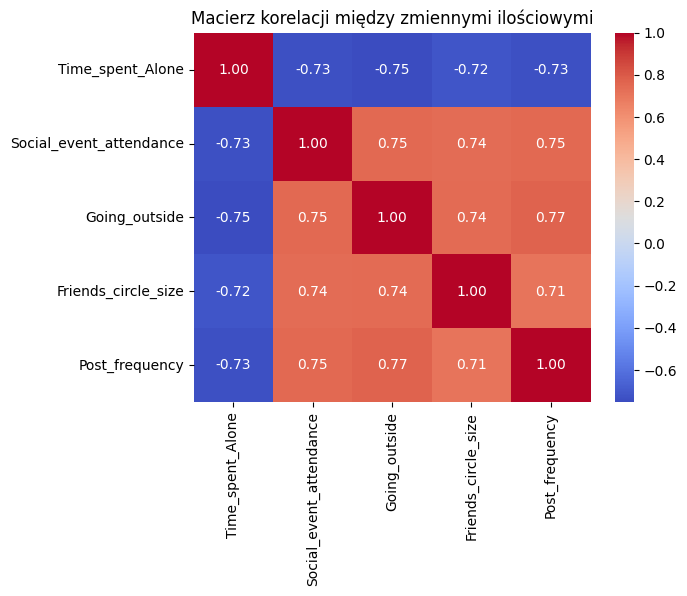

In [27]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji między zmiennymi ilościowymi")


Zmienna Time_spent_Alone jest silnie i ujemnie skorelowana ze wszystkimi pozostałymi zmiennymi w zestawieniu (wyniki od -0.71 do -0.75). Oznacza to, że osoby, które spędzają więcej czasu w samotności:

- Rzadziej wychodzą z domu (Going_outside: -0.75) - jest to najsilniejsza ujemna korelacja w całym zestawieniu, co jest dość logicznym wynikiem.
- Rzadziej uczestniczą w wydarzeniach towarzyskich (Social_event_attendance: -0.73).
- Mniej publikują w internecie/mediach społecznościowych (Post_frequency: -0.73).
- Mają mniejsze grono znajomych (Friends_circle_size: -0.71).

Pozostałe cztery zmienne (Social_event_attendance, Going_outside, Friends_circle_size, Post_frequency) są ze sobą silnie i dodatnio skorelowane (wyniki w przedziale od 0.71 do 0.77). Wskazuje to na istnienie spójnego "pakietu" zachowań społecznych. Jeśli dana osoba wykazuje wysoki poziom jednej z tych aktywności, z dużym prawdopodobieństwem jest bardzo aktywna również w pozostałych. Zauważalne tendencje to:

- Związek wyjść z aktywnością online: Najsilniejsza korelacja dodatnia w całej tabeli występuje między częstym wychodzeniem z domu (Going_outside) a częstotliwością publikowania postów (Post_frequency wynoszące 0.77). Osoby, które są aktywne w świecie rzeczywistym, chętniej dokumentują i dzielą się tym w przestrzeni wirtualnej.

- Towarzyskość napędza się nawzajem: Uczestnictwo w wydarzeniach towarzyskich i częste wyjścia idą w parze z posiadaniem rozbudowanego kręgu przyjaciół.

# 8. Wnioski końcowe

* **Typowe wartości analizowanych cech:** Badana populacja dzieli się niemal symetrycznie na ekstrawertyków (51,4%) i introwertyków (48,6%). Podobnie równy podział dotyczy cech jakościowych: połowa badanych odczuwa lęk przed wystąpieniami publicznymi (`Stage_fear`) oraz wyczerpanie po interakcjach społecznych (`Drained_after_socializing`). Pod kątem wartości liczbowych, typowy badany spędza w samotności około 4 jednostek czasu dziennie, ma 5 bliskich znajomych, rzadko publikuje posty w sieci (mediana 3) i wychodzi z domu z umiarkowaną częstotliwością (mediana 3).

* **Zróżnicowanie danych:** Wszystkie analizowane zachowania ilościowe charakteryzują się **bardzo silnym zróżnicowaniem** - współczynniki zmienności dla całej populacji wahają się od 68% do blisko 82%. Oznacza to, że odchylenia od średniej są ogromne, a w badanej grupie nie ma jednego "standardowego" modelu zachowania. Najbardziej skrajnie zróżnicowaną cechą jest aktywność w social mediach (`Post_frequency` - wsp. zmienności ok. 81,9%), co pokazuje ogromny rozstrzał między osobami całkowicie biernymi cyfrowo a bardzo aktywnymi. Najmniejsze (choć wciąż statystycznie bardzo wysokie) zróżnicowanie występuje w przypadku kręgu znajomych (`Friends_circle_size` - ok. 68,0%). 

* **Obserwacje odstające (Outliery):** Rozkłady zmiennych nie wykazują skrajnych anomalii, a większość cech charakteryzuje się prawoskośnością. Zjawisko wartości odstających ujawnia się jednak wyraźnie podczas podziału na grupy docelowe. Przykładem jest czas spędzany w samotności u ekstrawertyków. Choć zdecydowana większość z nich unika samotności, na wykresach ramkowych uwidoczniła się nieliczna, ale istotna grupa ekstrawertyków, którzy spędzają w izolacji niezwykle dużo czasu (nawet do 11 jednostek), co stanowi silne odchylenie od ogólnego trendu tej grupy.

* **Różnice między grupami:** Zmienna `Personality` różnicuje zachowania badanych. Introwertycy zachowują się bardziej jednorodnie w swoim zamiłowaniu do samotności - spędzają sami średnio 7 jednostek czasu (mediana 7), a rozkład tej cechy jest u nich nieco szerszy (rozstęp międzykwartylowy IQR = 4) w porównaniu do ekstrawertyków (IQR = 2, mediana 2). 

* **Zależności między zmiennymi:** Analiza korelacji ujawniła dwa silne, przeciwstawne pakiety zachowań. Zmienna `Time_spent_Alone` jest silnie, negatywnie skorelowana ze wszystkimi pozostałymi metrykami (korelacje rzędu -0,71 do -0,75). Im więcej czasu jednostka spędza w izolacji, tym niższa jest jej aktywność społeczna, liczba znajomych i częstotliwość wyjść. Z drugiej strony, pozostałe zachowania napędzają się wzajemnie: częste wyjścia z domu, duże grono znajomych, uczestnictwo w wydarzeniach towarzyskich oraz aktywność cyfrowa (`Post_frequency`) są ze sobą bardzo silnie i dodatnio skorelowane (od 0,71 do 0,77). Życie towarzyskie w świecie rzeczywistym idzie tu wyraźnie w parze z aktywnością w świecie wirtualnym.
